In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install lightgbm -q

In [3]:
train_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v3.csv"

train_df = pd.read_csv(train_path)

print(train_df.shape)

train_df.head()

(242965, 88)


,acc_resultant_mean,acc_resultant_std,acc_resultant_variance,acc_resultant_min,acc_resultant_max,acc_resultant_median,acc_resultant_rms,acc_resultant_skewness,acc_resultant_kurtosis,acc_resultant_q25,...,yaw_rms,yaw_skewness,yaw_kurtosis,yaw_q25,yaw_q75,yaw_iqr,driver,trip,road_type,behavior
0,0.062950,0.037494,0.001406,0.012961,0.178804,0.058821,0.073110,0.994585,0.711390,0.033116,...,0.026448,0.142478,-1.728146,-0.03325,-0.01400,0.01925,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE
1,0.060696,0.034344,0.001179,0.012961,0.144686,0.056502,0.069598,0.821860,0.113281,0.033116,...,0.026217,0.081806,-1.758558,-0.03325,-0.01400,0.01925,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE
2,0.060563,0.034495,0.001190,0.012961,0.144686,0.056502,0.069556,0.807773,0.093973,0.033116,...,0.025936,0.018867,-1.769954,-0.03325,-0.01375,0.01950,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE
3,0.059966,0.034357,0.001180,0.012961,0.144686,0.053694,0.068969,0.863860,0.203253,0.033116,...,0.025623,-0.041783,-1.764851,-0.03325,-0.01300,0.02025,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE
4,0.059171,0.033793,0.001142,0.012961,0.144686,0.053694,0.068001,0.933059,0.452223,0.033116,...,0.025261,-0.102163,-1.749063,-0.03225,-0.01300,0.01925,D6,20151221120051-26km-D6-AGGRESSIVE-MOTORWAY,MOTORWAY,AGGRESSIVE


In [4]:
target_column = "behavior"

feature_columns = [

    col

    for col in train_df.columns

    if col not in [

        "behavior",
        "driver",
        "trip",
        "road_type"

    ]

]

X = train_df[feature_columns]

y = train_df[target_column]

groups = train_df["trip"]

print(X.shape)

print(groups.nunique())

(242965, 84)
32


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [6]:
from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(
    n_splits=6
)

In [7]:
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [8]:
lgbm_model = LGBMClassifier(
    objective="multiclass",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

In [9]:
fold_results = []

confusion_matrices = []

feature_importances = []

fold = 1

for train_idx, val_idx in group_kfold.split(X, y, groups):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y[train_idx]
    y_val = y[val_idx]

    lgbm_model.fit(
        X_train,
        y_train
    )

    y_pred = lgbm_model.predict(X_val)

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    print(f"Accuracy : {accuracy:.4f}")

    print(
        classification_report(
            y_val,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_val,
        y_pred
    )

    confusion_matrices.append(cm)

    feature_importances.append(
        lgbm_model.feature_importances_
    )

    fold_results.append({
        "Fold": fold,
        "Accuracy": accuracy
    })

    fold += 1

Fold 1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.709972 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20166
[LightGBM] [Info] Number of data points in the train set: 199862, number of used features: 80
[LightGBM] [Info] Start training from score -1.360170
[LightGBM] [Info] Start training from score -1.484497
[LightGBM] [Info] Start training from score -0.660164
Accuracy : 0.4597
              precision    recall  f1-score   support

  AGGRESSIVE       0.67      0.64      0.65     12473
      DROWSY       0.47      0.10      0.16     17709
      NORMAL       0.37      0.78      0.50     12921

    accuracy                           0.46     43103
   macro avg       0.50      0.51      0.44     43103
weighted avg       0.50      0.46      0.41     43103

Fold 2
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.197568 seconds.
You can set `force_col_wise=tr

In [10]:
results_df = pd.DataFrame(
    fold_results
)

print(results_df)

print()

print(
    f"Mean Accuracy : {results_df['Accuracy'].mean():.4f}"
)

print(
    f"Std Accuracy : {results_df['Accuracy'].std():.4f}"
)

   Fold  Accuracy
0     1  0.459690
1     2  0.368271
2     3  0.505463
3     4  0.467220
4     5  0.364161
5     6  0.606250

Mean Accuracy : 0.4618
Std Accuracy : 0.0907


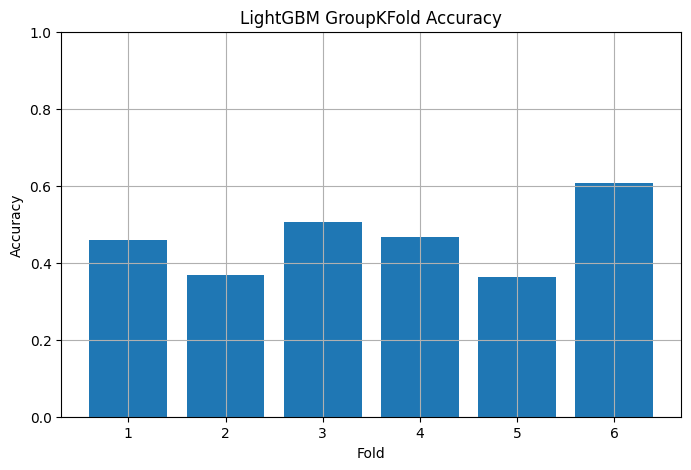

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Fold"],
    results_df["Accuracy"]
)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("LightGBM GroupKFold Accuracy")

plt.ylim(0,1)

plt.grid(True)

plt.show()

In [12]:
importance = np.mean(
    feature_importances,
    axis=0
)

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
78,yaw_rms,1696.833333
28,speed_max,1641.666667
76,yaw_max,1629.500000
75,yaw_min,1576.500000
27,speed_min,1197.500000
51,roll_min,1122.166667
52,roll_max,911.833333
63,pitch_min,910.833333
64,pitch_max,852.666667
40,speed_delta_max,783.666667


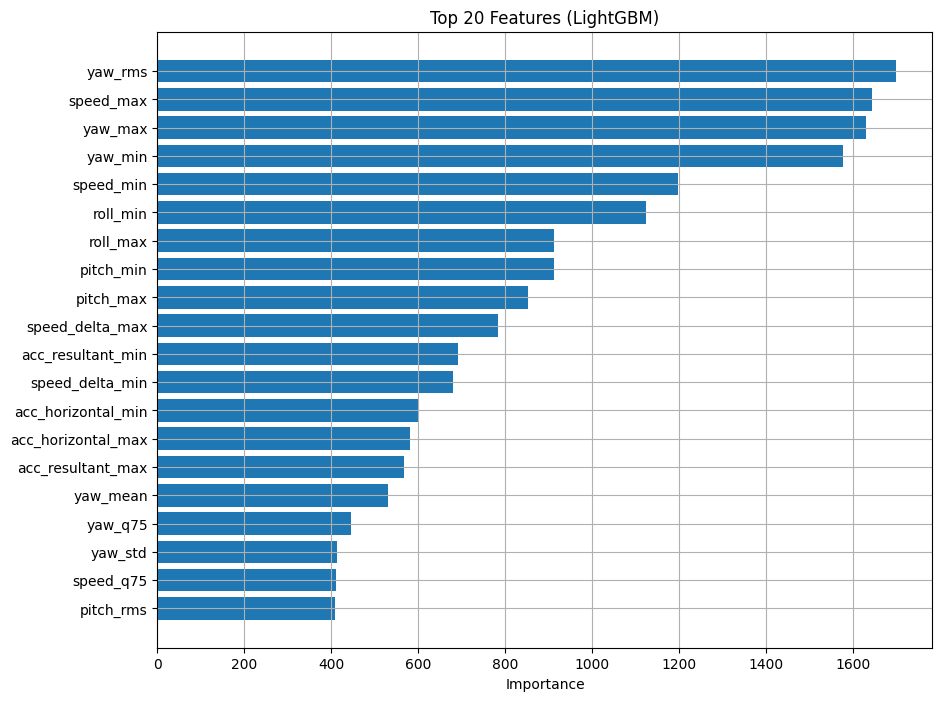

In [13]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:20][::-1],
    feature_importance["Importance"][:20][::-1]
)

plt.title("Top 20 Features (LightGBM)")

plt.xlabel("Importance")

plt.grid(True)

plt.show()

In [14]:
results_df.to_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/results/lightgbm_groupkfold_results.csv",
    index=False
)

feature_importance.to_csv(
    "/content/drive/MyDrive/TOGG_Driver_Risk_Project/results/lightgbm_feature_importance.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
